# Bike Sharing Analysis - Time Series with Prophet

Import Libraries and Mount Google Drive

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
from prophet import Prophet

In [2]:
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive

Mounted at /gdrive
/gdrive


# Import Dataset

In [3]:
df = pd.read_csv('/gdrive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Modern Time Series Forecasting Techniques /Prophet/Daily Bike Sharing training.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Create a copy of the dataframe for various EDA purposes

In [4]:
df_copy = pd.read_csv('/gdrive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Modern Time Series Forecasting Techniques /Prophet/Daily Bike Sharing training.csv',index_col='dteday',parse_dates=True)
df_copy.rename_axis(None, inplace=True)
df_copy.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
2011-01-01,1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
2011-01-02,2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2011-01-03,3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
2011-01-04,4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
2011-01-05,5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
df['y'] = df['cnt']
df['ds'] = df['dteday']
df['ds'] = pd.to_datetime(df['ds'],format='%m/%d/%Y')
df.drop(['cnt','dteday'], axis=1, inplace=True)
df.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y,ds
0,1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,2011-01-01
1,2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,2011-01-02
2,3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,2011-01-03
3,4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,2011-01-04
4,5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,2011-01-05


In [6]:
df_copy['y'] = df_copy['cnt']
df_copy.drop(['cnt'], axis=1, inplace=True)
df_copy.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,y
2011-01-01,1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
2011-01-02,2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2011-01-03,3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
2011-01-04,4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
2011-01-05,5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Code the `weathersit` categorical variable

In [7]:
weather_sit = pd.get_dummies(df['weathersit'], drop_first=True, prefix='weathersit')
df = pd.concat([df, weather_sit], axis=1)
df.drop(['weathersit'], axis=1, inplace=True)
df.head()

,instant,season,yr,mnth,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,y,ds,weathersit_2,weathersit_3
0,1,1,0,1,0,6,0,0.344167,0.363625,0.805833,0.160446,331,654,985,2011-01-01,True,False
1,2,1,0,1,0,0,0,0.363478,0.353739,0.696087,0.248539,131,670,801,2011-01-02,True,False
2,3,1,0,1,0,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,2011-01-03,False,False
3,4,1,0,1,0,2,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,2011-01-04,False,False
4,5,1,0,1,0,3,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,2011-01-05,False,False


Drop variables that are not needed...

* `instant:` just an index...not needed
* `season:` - inferred by Prophet
* `mnth:` - retrieved from `ds` column
* `yr:` - retrieved from `ds` column
* `weekday:` - retrieved from `ds` column
* `casual:` - scalar of `y`
* `registered:` - scalar of `y`

In [8]:
df.drop(columns = ['instant','season','mnth','yr','weekday','casual','registered'],inplace=True)
df.head()

,holiday,workingday,temp,atemp,hum,windspeed,y,ds,weathersit_2,weathersit_3
0,0,0,0.344167,0.363625,0.805833,0.160446,985,2011-01-01,True,False
1,0,0,0.363478,0.353739,0.696087,0.248539,801,2011-01-02,True,False
2,0,1,0.196364,0.189405,0.437273,0.248309,1349,2011-01-03,False,False
3,0,1,0.200000,0.212122,0.590435,0.160296,1562,2011-01-04,False,False
4,0,1,0.226957,0.229270,0.436957,0.186900,1600,2011-01-05,False,False


From EDA, we know that the $y$ values for `ds='2012-10-29'` and `ds='2012-10-30'` are erroneous and need to be replaced with the $y$ value for `ds='2012-10-28'`


In [9]:
df[df['ds'].isin(['2012-10-29','2012-10-30'])]

,holiday,workingday,temp,atemp,hum,windspeed,y,ds,weathersit_2,weathersit_3
667,0,1,0.440000,0.439400,0.880000,0.358200,22,2012-10-29,False,True
668,0,1,0.318182,0.309909,0.825455,0.213009,1096,2012-10-30,True,False


In [10]:
new_y_val = df.loc[df['ds'] == '2012-10-28'].y.values[0]
new_y_val

np.int64(4459)

In [11]:
df.loc[df['ds'].isin(['2012-10-29', '2012-10-30']), 'y'] = new_y_val
df[df['ds'].isin(['2012-10-28','2012-10-29', '2012-10-30'])].y

,y
666,4459
667,4459
668,4459


In [12]:
df_copy.drop(columns = ['instant','season','mnth','yr','weekday','casual','registered'],inplace=True)
df_copy.head()

,holiday,workingday,weathersit,temp,atemp,hum,windspeed,y
2011-01-01,0,0,2,0.344167,0.363625,0.805833,0.160446,985
2011-01-02,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2011-01-03,0,1,1,0.196364,0.189405,0.437273,0.248309,1349
2011-01-04,0,1,1,0.200000,0.212122,0.590435,0.160296,1562
2011-01-05,0,1,1,0.226957,0.229270,0.436957,0.186900,1600


# Useful Functions

In [13]:
# Function to assess model and visualize output

def model_assessment(train, test, predictions, chart_title):

  # Set the size of the plot to 10 inches by 4 inches
  plt.figure(figsize = (10,4))

  # Plot the train, test, and forecast data
  plt.plot(train, label = 'Train')
  plt.plot(test, label = 'Test')
  plt.plot(predictions, label = "Forecast")

  # add title and legend to the plot
  plt.title(f"Train, Test and Predictions with {chart_title}")
  plt.legend()
  plt.show()

  # Calculating the MAE, RMSE, and MAPE
  mae = mean_absolute_error(test, predictions)
  rmse = root_mean_squared_error(test, predictions)
  mape = mean_absolute_percentage_error(test, predictions)

  # Print the calculated error metrics
  print(f"The MAE is {mae:.2f}")
  print(f"The RMSE is {rmse:.2f}")
  print(f"The MAPE is {100 * mape:.2f} %")

  return

# Function to plot the future

def plot_future(y, forecast, title):

  # Set the size of the plot to 10 inches by 4 inches
  plt.figure(figsize = (10,4))

  # Plot the train and forecast data
  plt.plot(y, label = 'Train')
  plt.plot(forecast, label = "Forecast")

  # add title and legend to the plot
  plt.title(f"Train and Forecast with {title}")
  plt.legend()
  plt.show()

  return

Plot the target variable `y`

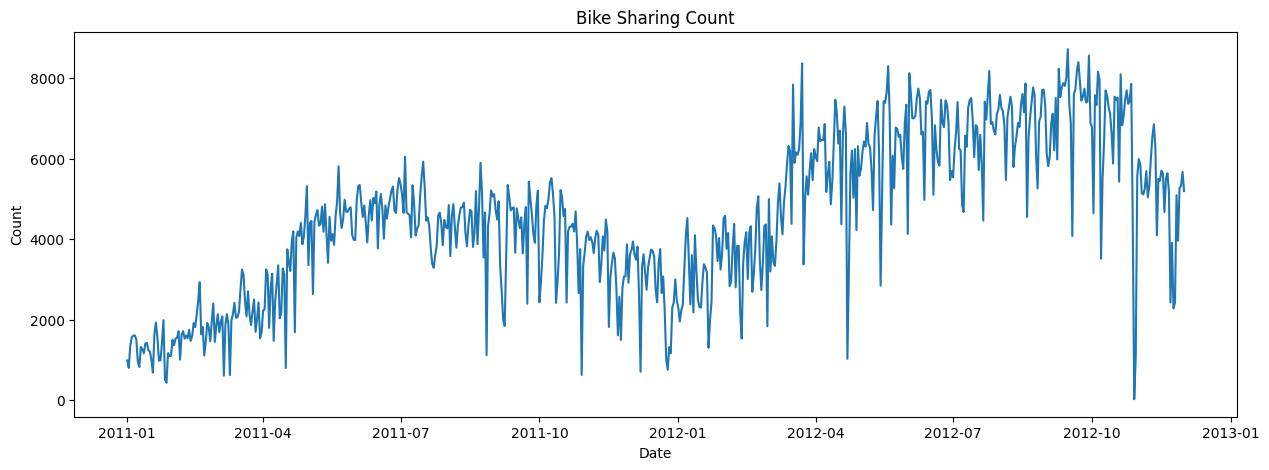

In [14]:
plt.figure(figsize = (15,5))
plt.plot(df_copy['y'])
plt.title('Bike Sharing Count')
plt.xlabel('Date')
plt.ylabel('Count')
plt.show()


In [15]:
df_copy = df_copy.asfreq('D')

# Month and Quarter Plots

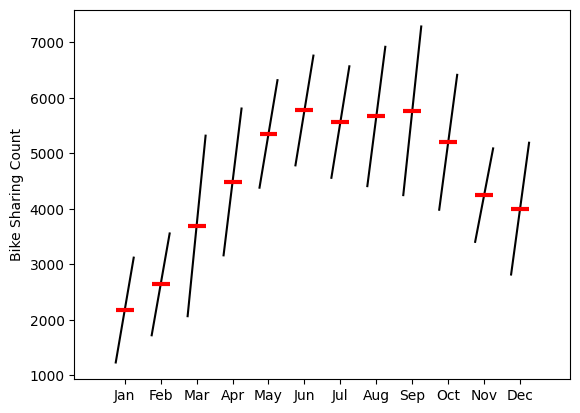

In [16]:
month_plot(df_copy['y'].resample('ME').mean())
plt.ylabel('Bike Sharing Count')
plt.show()

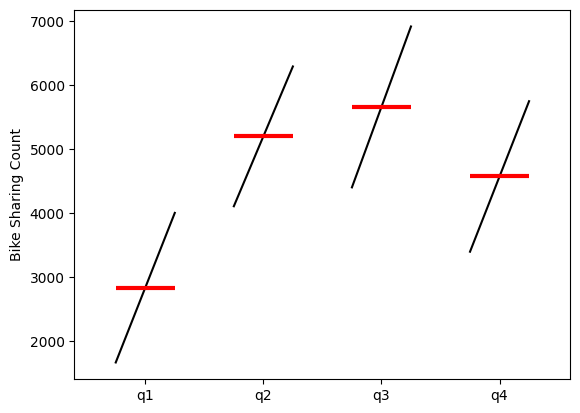

In [17]:
# Plot the quarter_plot
quarter_plot(df_copy['y'].resample('QE').mean())
plt.ylabel('Bike Sharing Count')
plt.show()


# Seasonal Decomposition

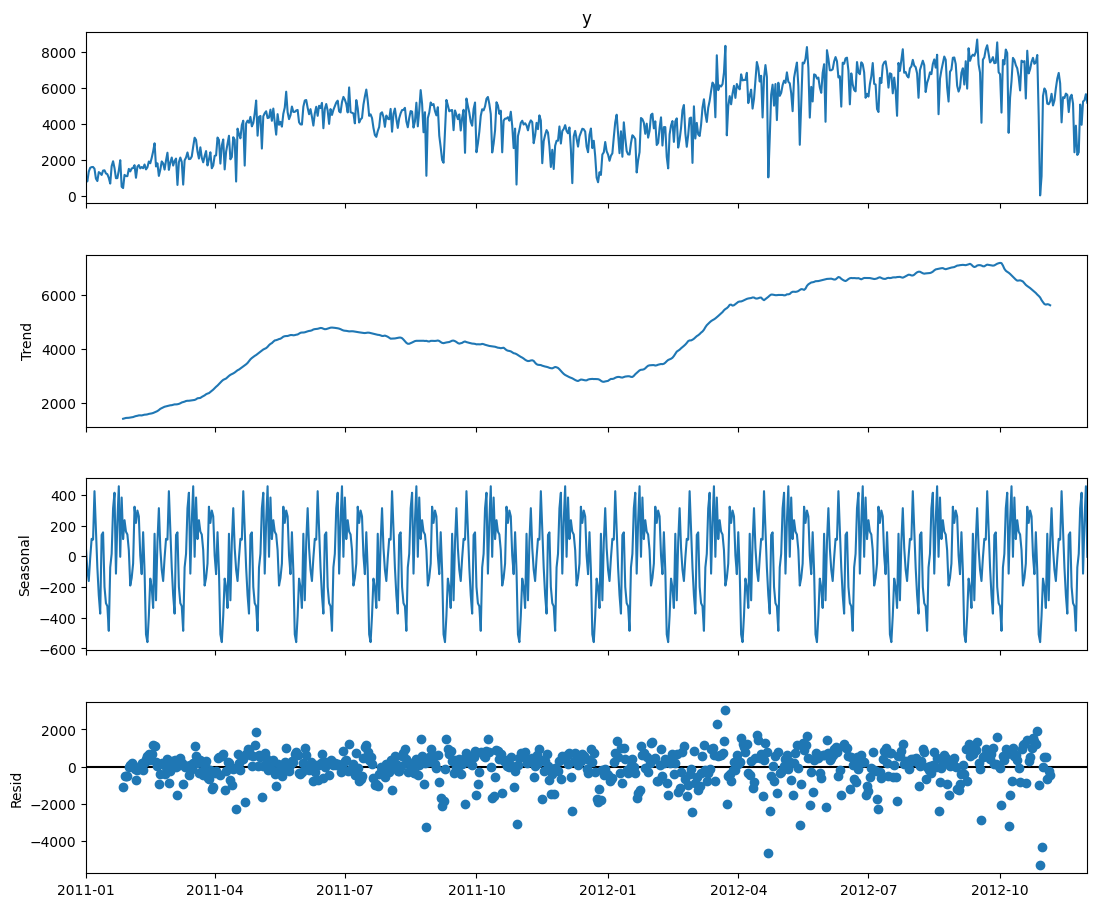

In [18]:
# Seasonal decomposition for df_copy['y']
decomposition = seasonal_decompose(df_copy['y'],
                                  model = 'additive',
                                  period = 52)
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.show()


# ACF & PACF

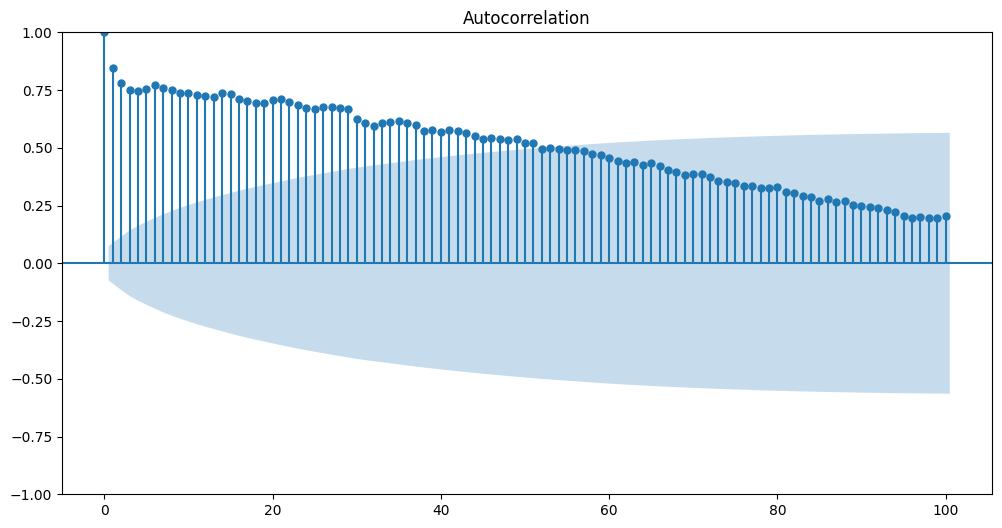

In [19]:
# Plot the ACF
fig, ax = plt.subplots(figsize = (12, 6))
plot_acf(df_copy['y'], lags = 100, ax = ax)
plt.show()


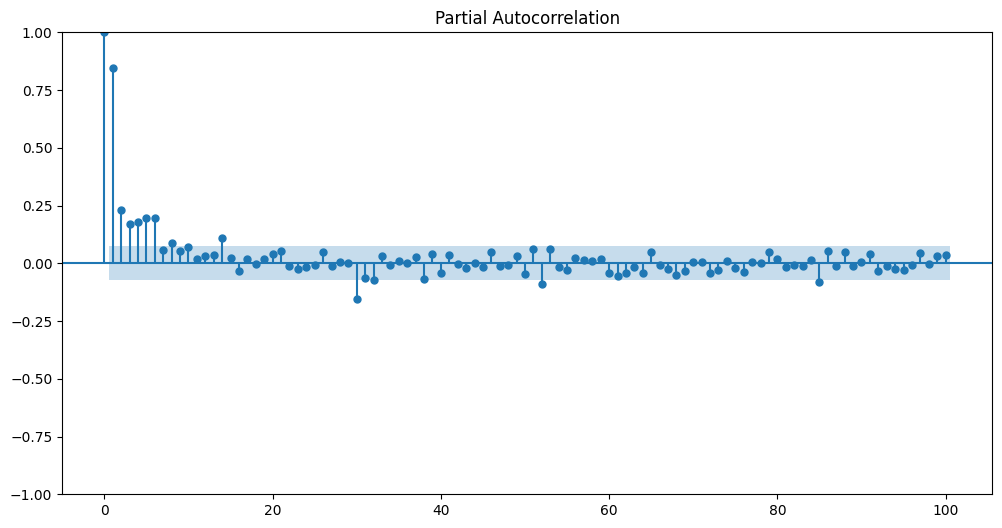

In [20]:
# PACF
fig, ax = plt.subplots(figsize = (12, 6))
plot_pacf(df_copy['y'], lags = 100, ax = ax)
plt.show()


# Stationarity

In [21]:
def adf_test(series, title=None):

  # Run the ADF test
  result = adfuller(series.dropna(), autolag='AIC')

  # Extract and print results
  print('ADF Statistic:', result[0])
  print('p-value:', result[1])
  print('Critical Values:')
  for key, value in result[4].items():
      print(f'   {key}: {value}')

  # Interpretation
  if result[1] < 0.05:
      print("Result: The series is likely stationary (reject H0).")
  else:
      print("Result: The series is likely non-stationary (fail to reject H0).")

In [22]:
adf_test(df_copy['y'])

ADF Statistic: -2.0185176281605512
p-value: 0.2785132482853741
Critical Values:
   1%: -3.439904442607456
   5%: -2.8657562268758907
   10%: -2.569015252972123
Result: The series is likely non-stationary (fail to reject H0).


Let's compute the difference of `df_copy.y`

In [23]:
df_copy['y_diff'] = df_copy['y'].diff().dropna()
df_copy.head()


,holiday,workingday,weathersit,temp,atemp,hum,windspeed,y,y_diff
2011-01-01,0,0,2,0.344167,0.363625,0.805833,0.160446,985,NaN
2011-01-02,0,0,2,0.363478,0.353739,0.696087,0.248539,801,-184.0
2011-01-03,0,1,1,0.196364,0.189405,0.437273,0.248309,1349,548.0
2011-01-04,0,1,1,0.200000,0.212122,0.590435,0.160296,1562,213.0
2011-01-05,0,1,1,0.226957,0.229270,0.436957,0.186900,1600,38.0


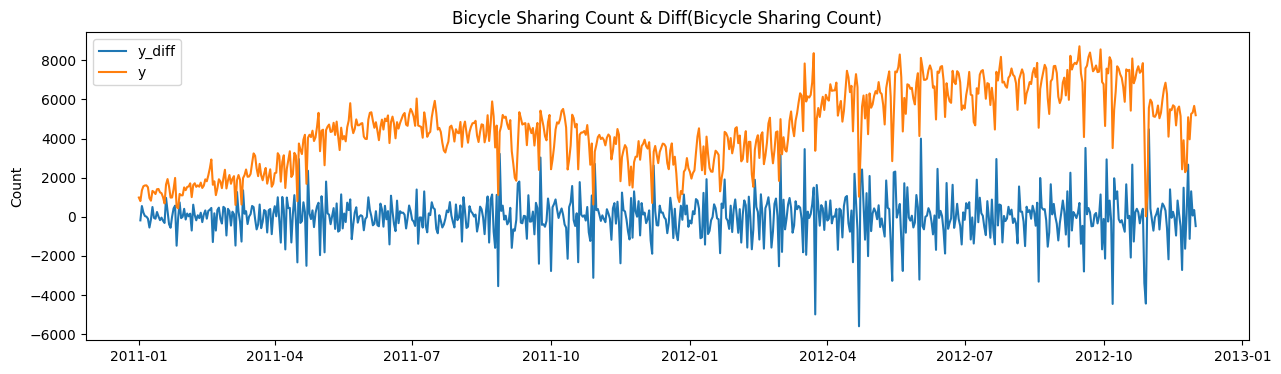

In [24]:
plt.figure(figsize = (15,4))
plt.plot(df_copy['y_diff'],label='y_diff')
plt.plot(df_copy['y'],label='y')
plt.legend()
plt.title("Bicycle Sharing Count & Diff(Bicycle Sharing Count)")
plt.ylabel("Count")
plt.show()

In [25]:
adf_test(df_copy['y_diff'])

ADF Statistic: -11.927665998038712
p-value: 4.863930539977401e-22
Critical Values:
   1%: -3.439904442607456
   5%: -2.8657562268758907
   10%: -2.569015252972123
Result: The series is likely stationary (reject H0).


# Holidays in the dataframe

In [26]:
df[df.holiday == 1].ds

,ds
16,2011-01-17
51,2011-02-21
104,2011-04-15
149,2011-05-30
184,2011-07-04
247,2011-09-05
282,2011-10-10
314,2011-11-11
327,2011-11-24
359,2011-12-26


Some of these holidays need to be defined further so we will define various holiday intervals.

In [27]:
# general holiday
gen_holidays = pd.DataFrame({'holiday': 'gen_holi',
                             'ds': df[df.holiday == 1].ds,
                             'lower_window': -2,
                             'upper_window': 2})
# Christmas
christmas = pd.DataFrame({'holiday': 'christmas',
                     'ds': pd.to_datetime(['2011-12-24', '2012-12-24']),
                             'lower_window': -5,
                             'upper_window': 3})
# New Year's eve
new_years = pd.DataFrame({'holiday': 'new_years',
                     'ds': pd.to_datetime(['2011-12-31', '2012-12-31']),
                             'lower_window': -3,
                             'upper_window': 3})
# Easter
easter = pd.DataFrame({'holiday': 'easter',
                     'ds': pd.to_datetime(['2011-04-24', '2012-04-08']),
                     'lower_window': -3,
                             'upper_window': 3})

In [28]:
christmas.head()

,holiday,ds,lower_window,upper_window
0,christmas,2011-12-24,-5,3
1,christmas,2012-12-24,-5,3


In [29]:
holidays = pd.concat([gen_holidays, christmas, new_years, easter])
holidays.head()

,holiday,ds,lower_window,upper_window
16,gen_holi,2011-01-17,-2,2
51,gen_holi,2011-02-21,-2,2
104,gen_holi,2011-04-15,-2,2
149,gen_holi,2011-05-30,-2,2
184,gen_holi,2011-07-04,-2,2


# Feature Engineering

Let's look at lags in the `temp` and `atemp` features:

In [45]:
for lag in [1,3,5,7]:
  df[f'temp_lag_{lag}'] = df['temp'].shift(lag)
  df[f'atemp_lag_{lag}'] = df['atemp'].shift(lag)
df.head()

,holiday,workingday,temp,atemp,hum,windspeed,y,ds,weathersit_2,weathersit_3,temp_lag_1,temp_lag_3,temp_lag_5,temp_lag_7,atemp_lag_1,atemp_lag_3,atemp_lag_5,atemp_lag_7
0,0,0,0.344167,0.363625,0.805833,0.160446,985,2011-01-01,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0,0.363478,0.353739,0.696087,0.248539,801,2011-01-02,True,False,0.344167,NaN,NaN,NaN,0.363625,NaN,NaN,NaN
2,0,1,0.196364,0.189405,0.437273,0.248309,1349,2011-01-03,False,False,0.363478,NaN,NaN,NaN,0.353739,NaN,NaN,NaN
3,0,1,0.200000,0.212122,0.590435,0.160296,1562,2011-01-04,False,False,0.196364,0.344167,NaN,NaN,0.189405,0.363625,NaN,NaN
4,0,1,0.226957,0.229270,0.436957,0.186900,1600,2011-01-05,False,False,0.200000,0.363478,NaN,NaN,0.212122,0.353739,NaN,NaN


Check correlations

In [46]:
# Create correlation matrix between the lagged values and y

columns = ['y'] + [col for col in df.columns if col.startswith('temp_lag_') or col.startswith('atemp_lag_')]
corr_matrix = df[columns].corr()
corr_matrix

,y,temp_lag_1,temp_lag_3,temp_lag_5,temp_lag_7,atemp_lag_1,atemp_lag_3,atemp_lag_5,atemp_lag_7
y,1.000000,0.590368,0.581922,0.589976,0.595830,0.586681,0.577076,0.587374,0.591886
temp_lag_1,0.590368,1.000000,0.892245,0.861173,0.864545,0.991526,0.882663,0.847990,0.852673
temp_lag_3,0.581922,0.892245,1.000000,0.891829,0.860613,0.877489,0.991519,0.882187,0.847451
temp_lag_5,0.589976,0.861173,0.891829,1.000000,0.891432,0.848465,0.877082,0.991490,0.881814
temp_lag_7,0.595830,0.864545,0.860613,0.891432,1.000000,0.853113,0.847940,0.876584,0.991475
atemp_lag_1,0.586681,0.991526,0.877489,0.848465,0.853113,1.000000,0.869430,0.836607,0.842372
atemp_lag_3,0.577076,0.882663,0.991519,0.877082,0.847940,0.869430,1.000000,0.868989,0.836076
atemp_lag_5,0.587374,0.847990,0.882187,0.991490,0.876584,0.836607,0.868989,1.000000,0.868539
atemp_lag_7,0.591886,0.852673,0.847451,0.881814,0.991475,0.842372,0.836076,0.868539,1.000000


Upon inspection of the correlation matrix, we see that all of the lags have a correlation with $y \approx 0.59$. Also, we see that correlation between `temp` and `atemp` is almost 1, so we can drop 1 of these variables. So we will just keep `temp_lag_1`.

In [47]:
df.drop(['temp_lag_3', 'temp_lag_5','temp_lag_7','atemp_lag_1', 'atemp_lag_3', 'atemp_lag_5', 'atemp_lag_7'], axis=1, inplace=True)
df.head()

,holiday,workingday,temp,atemp,hum,windspeed,y,ds,weathersit_2,weathersit_3,temp_lag_1
0,0,0,0.344167,0.363625,0.805833,0.160446,985,2011-01-01,True,False,NaN
1,0,0,0.363478,0.353739,0.696087,0.248539,801,2011-01-02,True,False,0.344167
2,0,1,0.196364,0.189405,0.437273,0.248309,1349,2011-01-03,False,False,0.363478
3,0,1,0.200000,0.212122,0.590435,0.160296,1562,2011-01-04,False,False,0.196364
4,0,1,0.226957,0.229270,0.436957,0.186900,1600,2011-01-05,False,False,0.200000


# Prophet Model

Drop any rows in the dataframe that contain null values as the Prophet model cannot handle them.

In [48]:
df.dropna(inplace=True)

In [49]:
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    holidays=holidays,
    seasonality_mode='multiplicative',
    seasonality_prior_scale=10,
    holidays_prior_scale=10,
    changepoint_prior_scale=0.05
    )
model_prophet.add_regressor('workingday')
model_prophet.add_regressor('temp')
model_prophet.add_regressor('atemp')
model_prophet.add_regressor('hum')
model_prophet.add_regressor('windspeed')
model_prophet.add_regressor('weathersit_2')
model_prophet.add_regressor('weathersit_3')
model_prophet.add_regressor('temp_lag_1')

model_prophet.fit(df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpw16y9zbn/nas374cg.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpw16y9zbn/0m79svhn.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=16765', 'data', 'file=/tmp/tmpw16y9zbn/nas374cg.json', 'init=/tmp/tmpw16y9zbn/0m79svhn.json', 'output', 'file=/tmp/tmpw16y9zbn/prophet_modelbbdakc8p/prophet_model-20250729231810.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
23:18:10 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:18:11 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [50]:
# Get Regressor Coefficients

from prophet.utilities import regressor_coefficients
coef_df = regressor_coefficients(model_prophet)

Interpreting the Coefficients

In [51]:
def interpret_multiplicative_coeffs(df):
    interpretations = []

    for _, row in df.iterrows():
        reg = row['regressor']
        coef = row['coef']
        center = row['center']

        # Direction of effect
        direction = "increases" if coef > 0 else "decreases" if coef < 0 else "has no effect on"

        # Strength descriptor
        magnitude = abs(coef)
        if magnitude > 0.7:
            strength = "strongly"
        elif magnitude > 0.3:
            strength = "moderately"
        elif magnitude > 0:
            strength = "weakly"
        else:
            strength = "negligibly"

        # Special handling for binary or categorical features
        if reg.startswith('weathersit_'):
            context = f"When weather situation is category {reg[-1]}, demand {direction} {strength}."
        elif reg == 'workingday':
            context = f"On a working day, demand {direction} {strength}."
        else:
            context = (f"A unit increase in '{reg}' (from centered value {center:.2f}) "
                       f"{direction} demand {strength} in a multiplicative way.")

        interpretations.append(context)

    return interpretations


In [52]:
interpret_multiplicative_coeffs(coef_df)

['On a working day, demand increases moderately.',
 "A unit increase in 'temp' (from centered value 0.50) increases demand strongly in a multiplicative way.",
 "A unit increase in 'atemp' (from centered value 0.48) increases demand moderately in a multiplicative way.",
 "A unit increase in 'hum' (from centered value 0.63) decreases demand moderately in a multiplicative way.",
 "A unit increase in 'windspeed' (from centered value 0.19) decreases demand moderately in a multiplicative way.",
 'When weather situation is category 2, demand decreases weakly.',
 'When weather situation is category 3, demand decreases moderately.',
 "A unit increase in 'temp_lag_1' (from centered value 0.50) decreases demand moderately in a multiplicative way."]

# Cross Validation

How many days does the dataset contain?

In [53]:
df.shape[0]

700

In [54]:
from prophet.diagnostics import cross_validation
df_cv = cross_validation(model_prophet,
                         period='15 days',
                         initial='521 days',
                         horizon='30 days',
                         parallel='processes')

INFO:prophet:Making 10 forecasts with cutoffs between 2012-06-19 00:00:00 and 2012-11-01 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7d1ab07a4e10>
DEBUG:cmdstanpy:input tempfile: /tmp/tmpw16y9zbn/4cg8alc_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpw16y9zbn/mk85i0i7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpw16y9zbn/7rmrlkmm.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpw16y9zbn/woip9m7l.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=27742', 'data', 'file=/tmp/tmpw16y9zbn/mk85i0i7.json', 'init=/tmp/tmpw16y9zbn/7rmrlkmm.json', 'output', 'file=/tmp/tmpw16y9zbn/prophet_modelhd325dog/prophet_model-20250729231830.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
DEBUG:cmdstanpy:CmdStan args

In [55]:
df_cv.head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2012-06-20,8218.107965,7488.280526,8926.991291,6211,2012-06-19
1,2012-06-21,8517.636438,7815.073053,9227.601439,5905,2012-06-19
2,2012-06-22,8155.284540,7483.208148,8850.048011,5823,2012-06-19
3,2012-06-23,7738.209754,7061.250532,8435.742619,7458,2012-06-19
4,2012-06-24,7891.994019,7130.802277,8561.162534,6891,2012-06-19


Calculate performance metrics

In [56]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head(100)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,3 days,1.591031e+06,1261.360842,1000.132174,0.174698,0.124849,0.166258,0.566667
1,4 days,1.426143e+06,1194.212092,934.742984,0.156520,0.116548,0.151778,0.566667
2,5 days,1.471865e+06,1213.204488,966.709165,0.157546,0.110663,0.153219,0.500000
3,6 days,1.146910e+06,1070.938755,852.419013,0.132846,0.089614,0.134467,0.533333
4,7 days,1.236445e+06,1111.955466,868.194133,0.131164,0.089614,0.136146,0.566667
5,8 days,1.001902e+06,1000.950416,764.596263,0.107564,0.087141,0.115711,0.600000
6,9 days,9.584884e+05,979.024188,763.311539,0.107518,0.093548,0.114192,0.600000
7,10 days,1.401179e+06,1183.713884,888.127403,0.128911,0.096708,0.131643,0.533333
8,11 days,1.492019e+06,1221.482273,908.185192,0.135645,0.096017,0.136172,0.600000
9,12 days,1.925474e+06,1387.614608,1072.709699,0.168293,0.115892,0.171555,0.533333


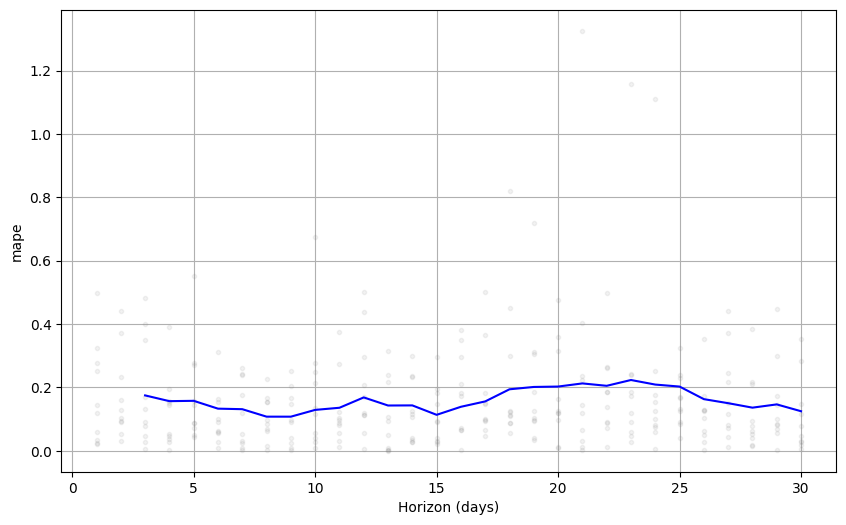

In [57]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='mape')

Let's explore this error...

The biggest percentage deviation seems to be happening on 10/29/2012.  What happened on that day?

It turns out that Hurricane Sandy hit Washington DC on that day.

In [40]:
# Compute the error/deviation

df_cv['deviation_%'] = (abs(df_cv['yhat'] - df_cv['y'])/df_cv['y'])*100
df_cv.sort_values(by='deviation_%', ascending=False).head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff,deviation_%
290,2012-11-22,5435.688200,4598.822334,6216.274170,2425,2012-11-01,124.152091
292,2012-11-24,4843.224866,3990.064192,5632.947651,2277,2012-11-01,112.702014
293,2012-11-25,4978.126345,4196.903613,5819.097166,2424,2012-11-01,105.368249
17,2012-07-07,8840.833157,8115.893396,9501.455374,4840,2012-06-19,82.661842
18,2012-07-08,8234.854497,7493.308372,8858.495435,4672,2012-06-19,76.259728


In [41]:
df[df['ds'].isin(['2012-10-29','2012-10-30'])]

,holiday,workingday,temp,atemp,hum,windspeed,y,ds,weathersit_2,weathersit_3,temp_lag_1,temp_lag_3,temp_lag_5,temp_lag_7
667,0,1,0.440000,0.439400,0.880000,0.358200,4459,2012-10-29,False,True,0.4775,0.545833,0.5875,0.487500
668,0,1,0.318182,0.309909,0.825455,0.213009,4459,2012-10-30,True,False,0.4400,0.530000,0.5500,0.544167


We really do not have any insight as to why the deviation is so high for 10/29 and 10/30 so what we will do is impute the $y$ value on 10/28 for this dates.

In [42]:
new_y_val = df.loc[df['ds'] == '2012-10-28'].y.values[0]
new_y_val

np.int64(4459)

In [43]:
df[df['ds'].isin(['2012-10-29','2012-10-30'])].y = new_y_val

In [44]:
df_p['mape'].max()

0.2210591308901493